# Exploratory Data Analysis of Kilter database

## Setup
Import key libraries and open a connection to the Kilter SQLite database.

In [92]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import re
conn = sqlite3.connect('../data/raw/kilter_database.sqlite')
cursor = conn.cursor()

## Database Overview
* Display tables and row counts
* Get schema info for key tables
* Get core statistics from key tables

In [83]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('shared_syncs',), ('products',), ('product_sizes',), ('holes',), ('leds',), ('products_angles',), ('layouts',), ('sets',), ('product_sizes_layouts_sets',), ('placement_roles',), ('users',), ('user_permissions',), ('user_syncs',), ('walls_sets',), ('climb_cache_fields',), ('attempts',), ('difficulty_grades',), ('climb_stats',), ('tags',), ('android_metadata',), ('circuits',), ('circuits_climbs',), ('kits',), ('climb_random_positions',), ('beta_links',), ('bids',), ('climbs',), ('placements',), ('walls',), ('ascents',), ('sqlite_stat1',)]


In [84]:
# Get row counts for each table
table_info = []
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [table[0] for table in cursor.fetchall()]

for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table};")
    row_count = cursor.fetchone()[0]
    table_info.append({'Table': table, 'Row Count': row_count})

table_stats = pd.DataFrame(table_info).sort_values('Row Count', ascending=False)
empty_tables = table_stats.loc[table_stats['Row Count'] == 0]
print(f"\nTotal Tables: {len(tables)}")
print(f"\nEmpty Tables:\n{empty_tables['Table'].tolist()}")
print(f"\nTable Statistics:\n{table_stats.drop(empty_tables.index).to_string(index=False)}")



Total Tables: 31

Empty Tables:
['ascents', 'walls', 'bids', 'walls_sets', 'climb_random_positions', 'circuits_climbs', 'circuits', 'tags', 'user_permissions', 'user_syncs', 'users']

Table Statistics:
                     Table  Row Count
               climb_stats     348028
                    climbs     344504
        climb_cache_fields     208457
                beta_links      32139
                      leds       7828
                placements       3773
                     holes       3294
                      kits        100
           products_angles         56
product_sizes_layouts_sets         41
         difficulty_grades         39
                  attempts         38
           placement_roles         30
              sqlite_stat1         24
             product_sizes         22
              shared_syncs         17
                      sets         11
                   layouts          8
                  products          7
          android_metadata          1

In [85]:
# Organize tables by category
table_categories = {
    'User Management': ['users', 'user_permissions', 'user_syncs'],
    'Climbs & Routes': ['climbs', 'climb_stats', 'climb_cache_fields', 'climb_random_positions', 'difficulty_grades', 'tags', 'beta_links'],
    'Attempts & Ascents': ['attempts', 'ascents', 'bids'],
    'Board Hardware': ['walls', 'products', 'product_sizes', 'holes', 'leds', 'products_angles', 'layouts', 'sets', 'placements', 'kits', 'product_sizes_layouts_sets', 'placement_roles', 'walls_sets'],
    'Circuits': ['circuits', 'circuits_climbs'],
    'Synchronization': ['shared_syncs', 'android_metadata'],
    'System': ['sqlite_stat1']
}

print("\n" + "="*60)
print("TABLE ORGANIZATION BY CATEGORY")
print("="*60)

for category, table_list in table_categories.items():
    existing_tables = [t for t in table_list if t in tables]
    if existing_tables:
        print(f"\n{category}:")
        for table in existing_tables:
            cursor.execute(f"SELECT COUNT(*) FROM {table};")
            count = cursor.fetchone()[0]
            print(f"  • {table}: {count:,} rows")



TABLE ORGANIZATION BY CATEGORY

User Management:
  • users: 0 rows
  • user_permissions: 0 rows
  • user_syncs: 0 rows

Climbs & Routes:
  • climbs: 344,504 rows
  • climb_stats: 348,028 rows
  • climb_cache_fields: 208,457 rows
  • climb_random_positions: 0 rows
  • difficulty_grades: 39 rows
  • tags: 0 rows
  • beta_links: 32,139 rows

Attempts & Ascents:
  • attempts: 38 rows
  • ascents: 0 rows
  • bids: 0 rows

Board Hardware:
  • walls: 0 rows
  • products: 7 rows
  • product_sizes: 22 rows
  • holes: 3,294 rows
  • leds: 7,828 rows
  • products_angles: 56 rows
  • layouts: 8 rows
  • sets: 11 rows
  • placements: 3,773 rows
  • kits: 100 rows
  • product_sizes_layouts_sets: 41 rows
  • placement_roles: 30 rows
  • walls_sets: 0 rows

Circuits:
  • circuits: 0 rows
  • circuits_climbs: 0 rows

Synchronization:
  • shared_syncs: 17 rows
  • android_metadata: 1 rows

System:
  • sqlite_stat1: 24 rows


In [87]:
# Get schema information for key tables
def get_table_schema(table_name):
    cursor.execute(f"PRAGMA table_info({table_name});")
    columns = cursor.fetchall()
    return columns

# Display schema for key tables
key_tables = ['climb_stats', 'climbs', 'climb_cache_fields', 'ascents', 'users', 'walls', 'attempts', 'beta_links']
for table in key_tables:
    if table in tables:
        print(f"\n{table.upper()} Schema:")
        schema = get_table_schema(table)
        for col in schema:
            print(f"  {col[1]} ({col[2]})")



CLIMB_STATS Schema:
  climb_uuid (TEXT)
  angle (INT UNSIGNED)
  display_difficulty (FLOAT UNSIGNED)
  benchmark_difficulty (FLOAT UNSIGNED)
  ascensionist_count (INT UNSIGNED)
  difficulty_average (FLOAT UNSIGNED)
  quality_average (FLOAT UNSIGNED)
  fa_username (TEXT)
  fa_at (TEXT)

CLIMBS Schema:
  uuid (TEXT)
  layout_id (INT UNSIGNED)
  setter_id (INT UNSIGNED)
  setter_username (TEXT)
  name (TEXT)
  description (TEXT)
  hsm (INT UNSIGNED)
  edge_left (INT UNSIGNED)
  edge_right (INT UNSIGNED)
  edge_bottom (INT UNSIGNED)
  edge_top (INT UNSIGNED)
  angle (INT)
  frames_count (INT UNSIGNED)
  frames_pace (INT UNSIGNED)
  frames (TEXT)
  is_draft (BOOLEAN)
  is_listed (BOOLEAN)
  created_at (TEXT)
  is_nomatch (BOOLEAN)

CLIMB_CACHE_FIELDS Schema:
  climb_uuid (TEXT)
  ascensionist_count (INT UNSIGNED)
  display_difficulty (FLOAT UNSIGNED)
  quality_average (FLOAT UNSIGNED)

ASCENTS Schema:
  uuid (TEXT)
  climb_uuid (TEXT)
  angle (INT UNSIGNED)
  is_mirror (BOOLEAN)
  user_id 

## Climbs and Routes
* Check for NULL values
* Display sample data from major tables

### Climb data completeness
Check NULL values across climbs and related tables.

In [72]:
# Check NULL values in climbs and related tables
print("="*60)
print("NULL VALUES IN CLIMBS & ROUTES TABLES")
print("="*60)

climb_related_tables = ['climbs', 'climb_stats', 'climb_cache_fields', 'difficulty_grades', 'beta_links']

for table in climb_related_tables:
    if table in tables:
        print(f"\n{table.upper()}:")
        schema = get_table_schema(table)
        cursor.execute(f"SELECT COUNT(*) FROM {table};")
        total = cursor.fetchone()[0]
        
        if total == 0:
            print("  (empty table)")
            continue
            
        has_nulls = False
        for col in schema:
            col_name = col[1]
            cursor.execute(f"SELECT COUNT(*) FROM {table} WHERE {col_name} IS NULL;")
            null_count = cursor.fetchone()[0]
            if null_count > 0:
                pct = (null_count / total) * 100
                print(f"  {col_name}: {null_count} NULLs ({pct:.1f}%)")
                has_nulls = True
        
        if not has_nulls:
            print("  (no NULL values)")


NULL VALUES IN CLIMBS & ROUTES TABLES

CLIMBS:
  angle: 103574 NULLs (30.1%)

CLIMB_STATS:
  benchmark_difficulty: 347394 NULLs (99.8%)

CLIMB_CACHE_FIELDS:
  ascensionist_count: 567 NULLs (0.3%)
  display_difficulty: 567 NULLs (0.3%)
  quality_average: 567 NULLs (0.3%)

DIFFICULTY_GRADES:
  (no NULL values)

BETA_LINKS:
  foreign_username: 6580 NULLs (20.5%)
  angle: 15106 NULLs (47.0%)
  thumbnail: 1000 NULLs (3.1%)


### Sample rows
Preview the first few records from major climb tables.

In [73]:
# Display sample data from major climb tables
print("\n" + "="*60)
print("SAMPLE DATA FROM MAJOR TABLES")
print("="*60)

major_climb_tables = ['climbs', 'climb_stats', 'climb_cache_fields', 'difficulty_grades', 'beta_links']

for table in major_climb_tables:
    if table in tables:
        cursor.execute(f"SELECT COUNT(*) FROM {table};")
        count = cursor.fetchone()[0]
        
        if count == 0:
            print(f"\n{table.upper()}: (empty)")
            continue
        
        print(f"\n{table.upper()} (first 5 rows):")
        df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
        print(df.to_string(index=False))



SAMPLE DATA FROM MAJOR TABLES

CLIMBS (first 5 rows):
                            uuid  layout_id  setter_id     setter_username                          name                              description  hsm  edge_left  edge_right  edge_bottom  edge_top angle  frames_count  frames_pace                                                                                                                                                                                                                                                                                   frames  is_draft  is_listed                 created_at  is_nomatch
002047402B6941CEA5ED7BB09FBFE14D          1       1051        kilterjackie 4/26 Harder Than It Should Be                                             3         40         136            4       152  None             1            0                                                                                                 p1145r12p1146r12p1149r13p1186r13p1201r13p1256r15

### Join preview
Join climbs with climb_stats and display a sample of the merged data.

In [69]:
# Join climbs and climb_stats tables
print("\n" + "="*60)
print("CLIMBS + CLIMB_STATS JOIN")
print("="*60)

join_query = """
SELECT c.*, cs.*
FROM climbs c
LEFT JOIN climb_stats cs ON c.uuid = cs.climb_uuid
LIMIT 5
"""

df_joined = pd.read_sql_query(join_query, conn)
print(f"\nJoined table shape: {df_joined.shape}")
print(f"\nFirst 5 rows:")
print(df_joined.to_string())



CLIMBS + CLIMB_STATS JOIN

Joined table shape: (5, 28)

First 5 rows:
                               uuid  layout_id  setter_id      setter_username                           name                               description  hsm  edge_left  edge_right  edge_bottom  edge_top angle  frames_count  frames_pace                                                                                                                                                                                                                                                                                    frames  is_draft  is_listed                  created_at  is_nomatch                        climb_uuid  angle  display_difficulty benchmark_difficulty  ascensionist_count  difficulty_average  quality_average   fa_username                fa_at
0  002047402B6941CEA5ED7BB09FBFE14D          1       1051         kilterjackie  4/26 Harder Than It Should Be                                              3         40         

### Difficulty distribution
Histogram of rounded route difficulty


DIFFICULTY AVERAGE DISTRIBUTION

Total climbs with difficulty data: 348028

Difficulty distribution by grade:
 difficulty_rounded boulder_name  count
               10.0        4a/V0   5769
               11.0        4b/V0   6837
               12.0        4c/V0   6032
               13.0        5a/V1   9278
               14.0        5b/V1  11203
               15.0        5c/V2  19492
               16.0        6a/V3  23740
               17.0       6a+/V3  23814
               18.0        6b/V4  28305
               19.0       6b+/V4  27601
               20.0        6c/V5  31368
               21.0       6c+/V5  28480
               22.0        7a/V6  38414
               23.0       7a+/V7  32354
               24.0        7b/V8  19697
               25.0       7b+/V8  13282
               26.0        7c/V9  11064
               27.0      7c+/V10   6371
               28.0       8a/V11   3118
               29.0      8a+/V12   1105
               30.0       8b/V13    297
         

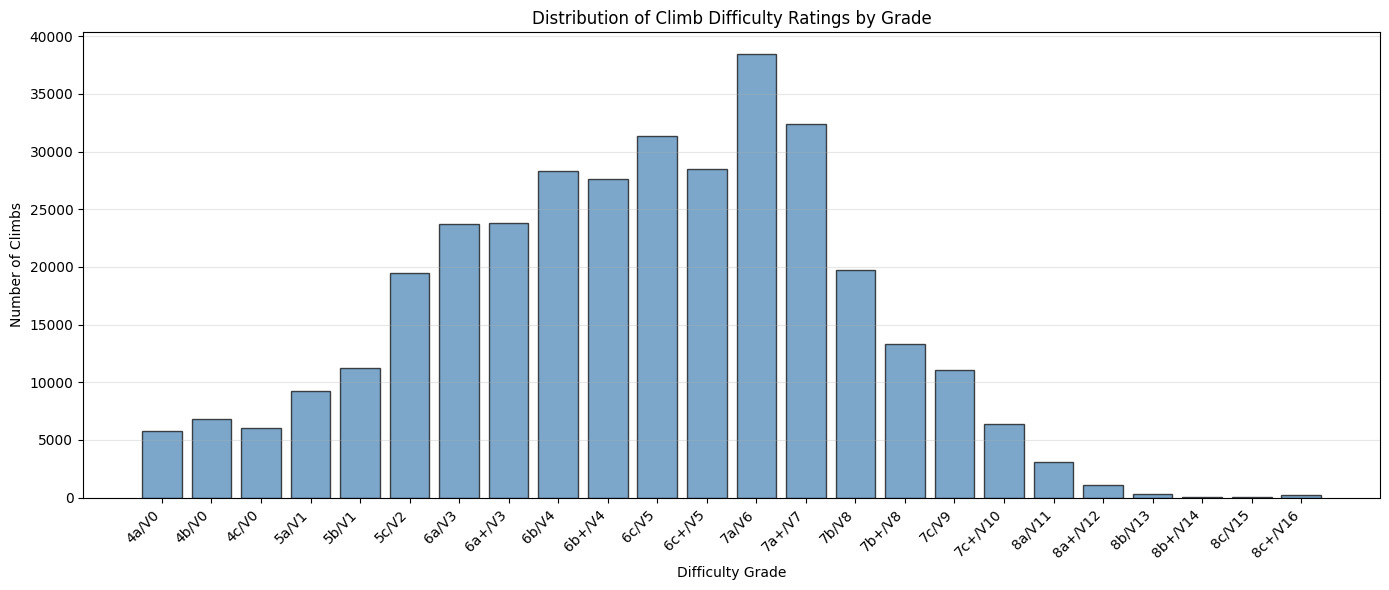

In [77]:
# Histogram of difficulty_average from climb_stats
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("DIFFICULTY AVERAGE DISTRIBUTION")
print("="*60)

# Round difficulty_average and join with difficulty_grades
difficulty_df = pd.read_sql_query("""
    SELECT 
        ROUND(cs.difficulty_average) as difficulty_rounded,
        dg.boulder_name,
        COUNT(*) as count
    FROM climb_stats cs
    LEFT JOIN difficulty_grades dg ON ROUND(cs.difficulty_average) = dg.difficulty
    WHERE cs.difficulty_average IS NOT NULL
    GROUP BY ROUND(cs.difficulty_average), dg.boulder_name
    ORDER BY difficulty_rounded
""", conn)

print(f"\nTotal climbs with difficulty data: {difficulty_df['count'].sum()}")
print(f"\nDifficulty distribution by grade:")
print(difficulty_df.to_string(index=False))

# Create histogram with boulder_name as x-axis labels
plt.figure(figsize=(14, 6))
plt.bar(range(len(difficulty_df)), difficulty_df['count'], edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Difficulty Grade')
plt.ylabel('Number of Climbs')
plt.title('Distribution of Climb Difficulty Ratings by Grade')
plt.xticks(range(len(difficulty_df)), difficulty_df['boulder_name'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Wall and Board Info

### Hardware data completeness
Check NULL values across board hardware tables.

In [78]:
# Check NULL values in board hardware tables
print("="*60)
print("NULL VALUES IN BOARD HARDWARE TABLES")
print("="*60)

board_hardware_tables = ['walls', 'products', 'product_sizes', 'holes', 'leds', 'products_angles', 'layouts', 'sets', 'placements', 'kits', 'product_sizes_layouts_sets', 'placement_roles', 'walls_sets']

for table in board_hardware_tables:
    if table in tables:
        print(f"\n{table.upper()}:")
        schema = get_table_schema(table)
        cursor.execute(f"SELECT COUNT(*) FROM {table};")
        total = cursor.fetchone()[0]
        
        if total == 0:
            print("  (empty table)")
            continue
        
        has_nulls = False
        for col in schema:
            col_name = col[1]
            cursor.execute(f"SELECT COUNT(*) FROM {table} WHERE {col_name} IS NULL;")
            null_count = cursor.fetchone()[0]
            if null_count > 0:
                pct = (null_count / total) * 100
                print(f"  {col_name}: {null_count} NULLs ({pct:.1f}%)")
                has_nulls = True
        
        if not has_nulls:
            print("  (no NULL values)")


NULL VALUES IN BOARD HARDWARE TABLES

WALLS:
  (empty table)

PRODUCTS:
  password: 7 NULLs (100.0%)

PRODUCT_SIZES:
  (no NULL values)

HOLES:
  (no NULL values)

LEDS:
  (no NULL values)

PRODUCTS_ANGLES:
  (no NULL values)

LAYOUTS:
  password: 2 NULLs (25.0%)

SETS:
  (no NULL values)

PLACEMENTS:
  default_placement_role_id: 1152 NULLs (30.5%)

KITS:
  (no NULL values)

PRODUCT_SIZES_LAYOUTS_SETS:
  (no NULL values)

PLACEMENT_ROLES:
  (no NULL values)

WALLS_SETS:
  (empty table)


### Hardware sample rows
Preview the first few records from major board hardware tables.

In [80]:
# Display sample data from board hardware tables
print("\n" + "="*60)
print("SAMPLE DATA FROM BOARD HARDWARE TABLES")
print("="*60)

major_board_tables = ['walls', 'products', 'product_sizes', 'holes', 'leds', 'products_angles', 'layouts', 'sets', 'placements', 'kits', 'product_sizes_layouts_sets', 'placement_roles', 'walls_sets']

for table in major_board_tables:
    if table in tables:
        cursor.execute(f"SELECT COUNT(*) FROM {table};")
        count = cursor.fetchone()[0]
        
        if count == 0:
            print(f"\n{table.upper()}: (empty)")
            continue
        
        print(f"\n{table.upper()} (first 5 rows):")
        df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
        print(df.to_string(index=False))



SAMPLE DATA FROM BOARD HARDWARE TABLES

WALLS: (empty)

PRODUCTS (first 5 rows):
 id                  name  is_listed password  min_count_in_frame  max_count_in_frame
  1 Kilter Board Original          1     None                   2                  35
  7 Kilter Board Homewall          1     None                   2                  35
  2                  JUUL          1     None                   2                  35
  3            Demo Board          0     None                   2                  35
  4             BKB Board          0     None                   2                  35

PRODUCT_SIZES (first 5 rows):
 id  product_id  edge_left  edge_right  edge_bottom  edge_top      name             description                   image_filename  position  is_listed
  8           1         24         120            0       156    8 x 12                    Home  product_sizes/8-transparent.png         1          1
 11           2          0         210            0       116 Full Wall

## Route Hold Data

### Parse frames and join with coordinates
Extract hold data from frames column and get x,y coordinates.

In [93]:

# Parse frames column and join with placements/holes to get coordinates
# Get all climbs with their frames
climbs_df = pd.read_sql_query("""
    SELECT uuid, name, frames
    FROM climbs
    WHERE frames IS NOT NULL
""", conn)

print(f"Total climbs to process: {len(climbs_df):,}")

# Parse frames and extract placement/role pairs
def parse_frames(frames_str):
    """Extract placement_id and role_id from frames string"""
    pattern = r'p(\d+)r(\d+)'
    return re.findall(pattern, frames_str)

# Parse all climbs and build a dataframe of holds
holds_data = []
for idx, row in climbs_df.iterrows():
    climb_uuid = row['uuid']
    climb_name = row['name']
    placements = parse_frames(row['frames'])
    
    for placement_id, role_id in placements:
        holds_data.append({
            'climb_uuid': climb_uuid,
            'climb_name': climb_name,
            'placement_id': int(placement_id),
            'role_id': int(role_id)
        })

holds_df = pd.DataFrame(holds_data)
print(f"\nTotal holds extracted: {len(holds_df):,}")
print(f"\nFirst few holds:")
print(holds_df.head(10).to_string(index=False))


Total climbs to process: 344,504

Total holds extracted: 4,623,164

First few holds:
                      climb_uuid                    climb_name  placement_id  role_id
002047402B6941CEA5ED7BB09FBFE14D 4/26 Harder Than It Should Be          1145       12
002047402B6941CEA5ED7BB09FBFE14D 4/26 Harder Than It Should Be          1146       12
002047402B6941CEA5ED7BB09FBFE14D 4/26 Harder Than It Should Be          1149       13
002047402B6941CEA5ED7BB09FBFE14D 4/26 Harder Than It Should Be          1186       13
002047402B6941CEA5ED7BB09FBFE14D 4/26 Harder Than It Should Be          1201       13
002047402B6941CEA5ED7BB09FBFE14D 4/26 Harder Than It Should Be          1256       15
002047402B6941CEA5ED7BB09FBFE14D 4/26 Harder Than It Should Be          1267       13
002047402B6941CEA5ED7BB09FBFE14D 4/26 Harder Than It Should Be          1276       15
002047402B6941CEA5ED7BB09FBFE14D 4/26 Harder Than It Should Be          1307       13
002047402B6941CEA5ED7BB09FBFE14D 4/26 Harder Than It Sh

In [94]:

# Join with placements and holes to get x,y coordinates
placements_df = pd.read_sql_query("SELECT id, hole_id FROM placements", conn)
holes_df = pd.read_sql_query("SELECT id, x, y FROM holes", conn)

# Merge holds with placements
holds_with_holes = holds_df.merge(
    placements_df, 
    left_on='placement_id', 
    right_on='id',
    how='left'
)

# Merge with holes to get coordinates
holds_with_coords = holds_with_holes.merge(
    holes_df,
    left_on='hole_id',
    right_on='id',
    how='left',
    suffixes=('_placement', '_hole')
)

print("="*60)
print("HOLDS WITH COORDINATES")
print("="*60)
print(f"\nTotal holds with coordinates: {len(holds_with_coords):,}")
print(f"Holds missing coordinates: {holds_with_coords['x'].isna().sum():,}")

print("\nSample holds with coordinates:")
print(holds_with_coords[['climb_name', 'placement_id', 'role_id', 'hole_id', 'x', 'y']].head(15).to_string(index=False))


HOLDS WITH COORDINATES

Total holds with coordinates: 4,623,164
Holds missing coordinates: 0

Sample holds with coordinates:
                   climb_name  placement_id  role_id  hole_id   x   y
4/26 Harder Than It Should Be          1145       12     1294  40  40
4/26 Harder Than It Should Be          1146       12     1341  48  40
4/26 Harder Than It Should Be          1149       13     1408  72  40
4/26 Harder Than It Should Be          1186       13     1509  96  56
4/26 Harder Than It Should Be          1201       13     1451  80  64
4/26 Harder Than It Should Be          1256       15     1560 112  88
4/26 Harder Than It Should Be          1267       13     1388  64  96
4/26 Harder Than It Should Be          1276       15     1647 136  96
4/26 Harder Than It Should Be          1307       13     1556 112 112
4/26 Harder Than It Should Be          1321       13     1480  88 120
4/26 Harder Than It Should Be          1322       13     1497  96 120
4/26 Harder Than It Should Be      

### Histogram of holds per route
Distribution of how many holds each climb uses.

HOLDS PER CLIMB STATISTICS
Total climbs: 344,504
Mean holds per climb: 13.4
Median holds per climb: 12
Min holds: 1
Max holds: 407
Std deviation: 6.4


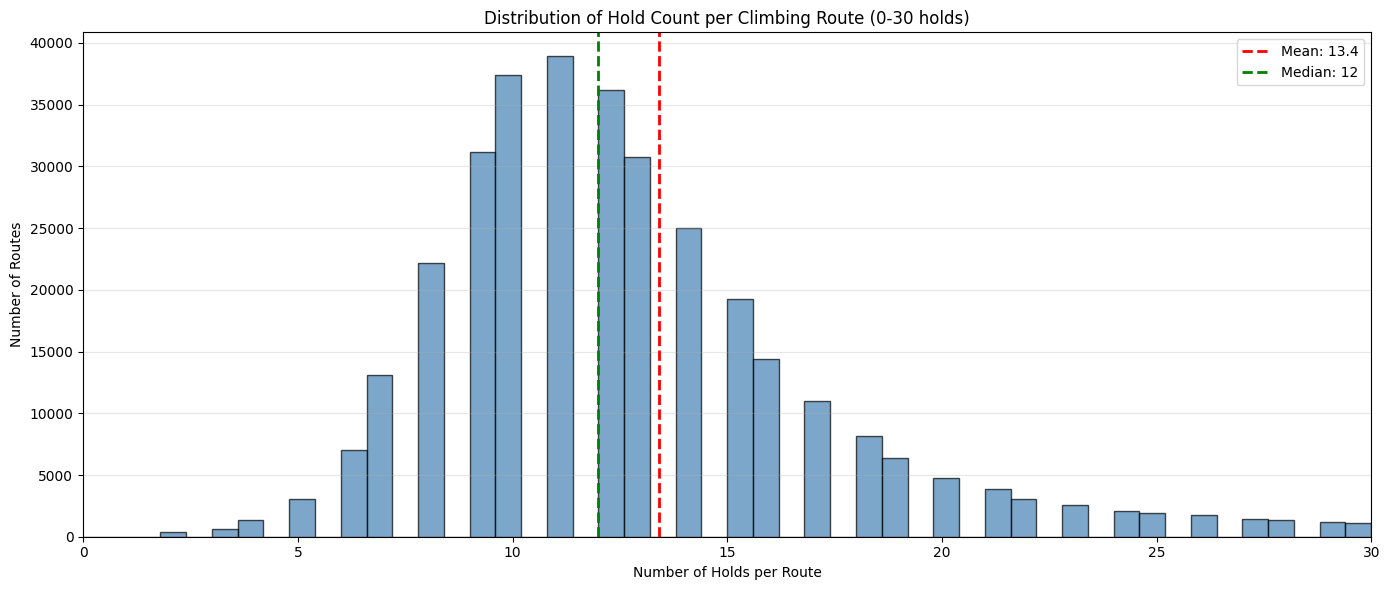


ROUTES WITH FEWEST HOLDS
                name  hold_count
                test           1
smallest climb ever2           2
     gxtftgycyghuvtg           2
           contact 2           2
          Test - 006           2

ROUTES WITH MOST HOLDS
                          name  hold_count
            Tetris a la Kilter         407
             Happy New Year! 🎉         394
        Twister 12x12 Original         306
                intro fra resi         270
TWP Spooky like Sunday Morning         247


In [96]:

# Count holds per climb
holds_per_climb = holds_with_coords.groupby('climb_uuid').size().reset_index(name='hold_count')

print("="*60)
print("HOLDS PER CLIMB STATISTICS")
print("="*60)
print(f"Total climbs: {len(holds_per_climb):,}")
print(f"Mean holds per climb: {holds_per_climb['hold_count'].mean():.1f}")
print(f"Median holds per climb: {holds_per_climb['hold_count'].median():.0f}")
print(f"Min holds: {holds_per_climb['hold_count'].min()}")
print(f"Max holds: {holds_per_climb['hold_count'].max()}")
print(f"Std deviation: {holds_per_climb['hold_count'].std():.1f}")

# Create histogram
plt.figure(figsize=(14, 6))
plt.hist(holds_per_climb['hold_count'], bins=50, edgecolor='black', alpha=0.7, color='steelblue', range=(0, 30))
plt.xlabel('Number of Holds per Route')
plt.ylabel('Number of Routes')
plt.title('Distribution of Hold Count per Climbing Route (0-30 holds)')
plt.xlim(0, 30)
plt.axvline(holds_per_climb['hold_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {holds_per_climb["hold_count"].mean():.1f}')
plt.axvline(holds_per_climb['hold_count'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {holds_per_climb["hold_count"].median():.0f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Show climbs with extreme hold counts
print("\n" + "="*60)
print("ROUTES WITH FEWEST HOLDS")
print("="*60)
fewest_holds = holds_per_climb.nsmallest(5, 'hold_count')
fewest_with_names = fewest_holds.merge(climbs_df[['uuid', 'name']], left_on='climb_uuid', right_on='uuid')
print(fewest_with_names[['name', 'hold_count']].to_string(index=False))

print("\n" + "="*60)
print("ROUTES WITH MOST HOLDS")
print("="*60)
most_holds = holds_per_climb.nlargest(5, 'hold_count')
most_with_names = most_holds.merge(climbs_df[['uuid', 'name']], left_on='climb_uuid', right_on='uuid')
print(most_with_names[['name', 'hold_count']].to_string(index=False))


In [ ]:
# Checking quality_average in climb_stats?
qa_df = pd.read_sql_query("""
SELECT
    COUNT(*) AS n_rows,
    SUM(CASE WHEN quality_average IS NULL THEN 1 ELSE 0 END) AS n_null,
    MIN(quality_average) AS min_quality,
    MAX(quality_average) AS max_quality,
    AVG(quality_average) AS mean_quality
FROM climb_stats
""", conn)
print(qa_df.to_string(index=False))

qa_dist = pd.read_sql_query("""
SELECT ROUND(quality_average, 1) AS quality_bin, COUNT(*) AS n
FROM climb_stats
WHERE quality_average IS NOT NULL
GROUP BY ROUND(quality_average, 1)
ORDER BY quality_bin
""", conn)
print("\nRounded quality distribution:")
print(qa_dist.head(20).to_string(index=False))
print("...")
print(qa_dist.tail(20).to_string(index=False))

 n_rows  n_null  min_quality  max_quality  mean_quality
 348028       0          1.0          3.0      2.786027

Rounded quality distribution:
 quality_bin      n
         1.0   5089
         1.2      6
         1.3    130
         1.4     21
         1.5   1121
         1.6     41
         1.7    554
         1.8    365
         1.9     81
         2.0  28720
         2.1    314
         2.2   1137
         2.3   8028
         2.4   3315
         2.5  15910
         2.6   5679
         2.7  17792
         2.8  26710
         2.9  20071
         3.0 212944
...
 quality_bin      n
         1.0   5089
         1.2      6
         1.3    130
         1.4     21
         1.5   1121
         1.6     41
         1.7    554
         1.8    365
         1.9     81
         2.0  28720
         2.1    314
         2.2   1137
         2.3   8028
         2.4   3315
         2.5  15910
         2.6   5679
         2.7  17792
         2.8  26710
         2.9  20071
         3.0 212944


In [4]:
# Can we see how quality_average is computed from this SQLite DB?
schema_hits = pd.read_sql_query("""
SELECT type, name, sql
FROM sqlite_master
WHERE sql IS NOT NULL
  AND lower(sql) LIKE '%quality_average%'
ORDER BY type, name
""", conn)
print(schema_hits[['type','name']].to_string(index=False))

if len(schema_hits):
    for _, r in schema_hits.iterrows():
        print("\n" + "="*80)
        print(f"{r['type']} {r['name']}")
        print("="*80)
        print(r['sql'])

   type                     name
  table       climb_cache_fields
  table              climb_stats
trigger climb_stats_after_delete
trigger climb_stats_after_insert
trigger climb_stats_after_update

table climb_cache_fields
CREATE TABLE climb_cache_fields (
    climb_uuid TEXT NOT NULL PRIMARY KEY,
    ascensionist_count INT UNSIGNED NULL DEFAULT NULL,
    display_difficulty FLOAT UNSIGNED NULL DEFAULT NULL,
    quality_average FLOAT UNSIGNED NULL DEFAULT NULL,
    FOREIGN KEY (climb_uuid) REFERENCES climbs(uuid) ON UPDATE CASCADE ON DELETE CASCADE
)

table climb_stats
CREATE TABLE climb_stats (
    climb_uuid TEXT NOT NULL,
    angle INT UNSIGNED NOT NULL,

    -- The display difficulty will be the benchmark_difficulty if it exists.
    -- Otherwise it will be the difficulty_average which is the community concensus difficulty.
    -- The display_difficulty is a client-only cache column to make filtering and sorting
    -- faster than having to check two columns.
    --
    display_dif